<a href="https://colab.research.google.com/github/weagan/Multi-Token-Prediction-MTP-/blob/main/DeepSeek_MTP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeepSeek‑style Multi‑Token Prediction (MTP) — PyTorch Demo

This notebook implements a **DeepSeek‑style MTP branch** on top of a small Transformer trunk.

We follow the structure:

$$
H \in \mathbb{R}^{B \times T \times d}
$$

1. **RMSNorm (enorm)**
$$
H^{(1)} = \mathrm{RMSNorm}_{\text{enorm}}(H)
$$

2. **Dimensionality reduction**
$$
H^{(2)} = H^{(1)} W_{\text{proj}}^\top, \quad W_{\text{proj}} \in \mathbb{R}^{d_r \times d}
$$

3. **Extra Transformer layer**
$$
H^{(3)} = \mathrm{TransformerLayer}_{\text{mtp}}(H^{(2)})
$$

4. **RMSNorm (hnorm)**
$$
H^{(4)} = \mathrm{RMSNorm}_{\text{hnorm}}(H^{(3)})
$$

5. **Shared LM head**
$$
Z = H^{(4)} W_{\text{head}}, \quad W_{\text{head}} \in \mathbb{R}^{d_r \times |V|}
$$

6. **Multi‑token prediction loss** (same logits used to predict multiple future tokens):

$$
\mathcal{L}_{\text{MTP}}
=
-\frac{1}{N}
\sum_{b,t,k}
\log \mathrm{softmax}(Z_{b,t,:})_{x_{b,t+k}},
$$

where we mask out invalid pairs with $t + k \ge T$.

We train on a deterministic 1/19 digit sequence, show losses, and inspect predictions.

In [1]:
# cell_id: xznQ0QJEQLEw
import math
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, *args, **kwargs: x

print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('GPU count:', torch.cuda.device_count())

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU count: 1


In [2]:
# cell_id: -OAvVnkOQLEy
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Hyperparameters and deterministic 1/19 dataset

In [3]:
# cell_id: lO1kzGJFQLEz
VOCAB_SIZE = 10  # digits 0–9
SEQ_LEN = 72     # increased to provide more context
TRAIN_SAMPLES = 8000 # increased training data
VAL_SAMPLES = 2000 # increased validation data (proportionally)
BATCH_SIZE = 128    # increased batch size

D_MODEL = 512       # increased trunk hidden size d
D_REDUCED = 256     # increased reduced dimension d_r in MTP branch
N_HEADS = 8
N_LAYERS_MAIN = 6   # increased trunk layers
K_FUTURE = 2       # number of future tokens per position

MAX_EPOCHS = 20
LR = 3e-4
WARMUP_STEPS = 100

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('Config set.')

Config set.


In [4]:
# cell_id: dBHgZBazQLEz
def get_1_over_19_digits_sequence(seq_len):
    """Generate digits from the decimal expansion of 1/19 (repeating cycle length 18)."""
    cycle = [0, 5, 2, 6, 3, 1, 5, 7, 8, 9, 4, 7, 3, 6, 8, 4, 2, 1]
    seq = []
    while len(seq) < seq_len:
        seq.extend(cycle)
    return seq[:seq_len]

def get_1_over_13_digits_sequence(seq_len):
    """Generate digits from the decimal expansion of 1/13 (repeating cycle length 6)."""
    cycle = [0, 7, 6, 9, 2, 3]
    seq = []
    while len(seq) < seq_len:
        seq.extend(cycle)
    return seq[:seq_len]

def get_1_over_17_digits_sequence(seq_len):
    """Generate digits from the decimal expansion of 1/17 (repeating cycle length 16)."""
    cycle = [0, 5, 8, 8, 2, 3, 5, 2, 9, 4, 1, 1, 7, 6, 4, 7]
    seq = []
    while len(seq) < seq_len:
        seq.extend(cycle)
    return seq[:seq_len]


class DeterministicSequenceDataset(Dataset):
    def __init__(self, num_samples, seq_len, vocab_size, sequence_generator_funcs):
        self.data = []
        for _ in range(num_samples):
            chosen_generator = random.choice(sequence_generator_funcs)
            sequence = chosen_generator(seq_len)
            self.data.append(torch.tensor(sequence, dtype=torch.long))
        self.data = torch.stack(self.data)

    def __len__(self):
        return self.data.size(0)

    def __getitem__(self, idx):
        return self.data[idx]

ALL_GENERATORS = [
    get_1_over_19_digits_sequence,
    get_1_over_13_digits_sequence,
    get_1_over_17_digits_sequence,
]

train_ds = DeterministicSequenceDataset(TRAIN_SAMPLES, SEQ_LEN, VOCAB_SIZE, ALL_GENERATORS)
val_ds = DeterministicSequenceDataset(VAL_SAMPLES, SEQ_LEN, VOCAB_SIZE, ALL_GENERATORS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

len(train_ds), len(val_ds)

(8000, 2000)

## RMSNorm implementation

In [5]:
# cell_id: C3MTPDYeQLE0
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # x: (..., dim)
        norm = x.pow(2).mean(dim=-1, keepdim=True)
        x_normed = x * torch.rsqrt(norm + self.eps)
        return x_normed * self.weight

# quick sanity check
tmp = torch.randn(2, 3, 5)
RMSNorm(5)(tmp).shape

torch.Size([2, 3, 5])

## DeepSeek‑style MTP model

We build:

- Token + positional embeddings
- **Main trunk**: custom Transformer encoder with `N_LAYERS_MAIN` layers
- **MTP branch**:
  - RMSNorm (enorm)
  - Linear projection `d_model → d_reduced`
  - Extra Transformer layer in reduced dimension
  - RMSNorm (hnorm)
  - LM head `d_reduced → vocab_size`

The logits `Z ∈ ℝ[B, T, V]` are then used to predict multiple future tokens per position.

In [6]:
# cell_id: 7ZWOSxnoQLE0
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, D = x.shape
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        attn_scores = attn_scores.masked_fill(mask, float('-inf'))
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_output = torch.matmul(attn_weights, v)
        attn_output = attn_output.transpose(1, 2).contiguous().view(B, T, D)
        return self.out_proj(attn_output)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None):
        super().__init__()
        d_ff = d_ff if d_ff is not None else 4 * d_model
        self.linear1 = nn.Linear(d_model, d_ff)
        self.gelu = nn.GELU()
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.gelu(self.linear1(x)))

class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff=None):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ff = FeedForward(d_model, d_ff)
        self.norm1 = RMSNorm(d_model)
        self.norm2 = RMSNorm(d_model)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, d_model, n_heads, n_layers, d_ff=None):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, d_ff) for _ in range(n_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

class DeepseekMTPModel(nn.Module):
    def __init__(self, vocab_size, d_model, d_reduced, n_heads, n_layers_main, k_future, max_len):
        super().__init__()
        self.k_future = k_future
        self.max_len = max_len

        self.token_embeddings = nn.Embedding(vocab_size, d_model)
        self.position_embeddings = nn.Embedding(max_len, d_model)

        self.trunk = TransformerEncoder(d_model, n_heads, n_layers_main)

        self.enorm = RMSNorm(d_model)
        self.proj = nn.Linear(d_model, d_reduced, bias=False)
        self.mtp_layer = TransformerEncoderLayer(d_reduced, n_heads)
        self.hnorm = RMSNorm(d_reduced)
        self.lm_head = nn.Linear(d_reduced, vocab_size, bias=False)

    def forward(self, x):
        B, T = x.shape
        assert T <= self.max_len
        token_embeds = self.token_embeddings(x)
        pos_ids = torch.arange(T, device=x.device)
        pos_embeds = self.position_embeddings(pos_ids).unsqueeze(0)
        h = token_embeds + pos_embeds
        h = self.trunk(h)
        h_enorm = self.enorm(h)
        h_proj = self.proj(h_enorm)
        h_mtp = self.mtp_layer(h_proj)
        h_hnorm = self.hnorm(h_mtp)
        # 🧡✅ Logits for *each position t* in the sequence are generated here. These are the single predictions for all K_FUTURE steps.
        logits = self.lm_head(h_hnorm)  # (B, T, V) guesses that the robot will use to predict all K_FUTURE upcoming numbers!
        return logits

    def mtp_loss(self, x_true):
        # 🧡✅ The 'logits' from the forward pass are used here.
        # For each position `t`, logits[b, t, :] represents the model's single prediction distribution
        # for all future tokens (x_{b, t+1}, ..., x_{b, t+K}).
        logits = self(x_true)  # (B, T, V)
        B, T, V = logits.shape
        K = self.k_future
        device = x_true.device

        t_idx = torch.arange(T, device=device).view(1, T, 1)
        k_idx = torch.arange(1, K + 1, device=device).view(1, 1, K)
        t_future = t_idx + k_idx  # (1, T, K)

        valid_mask = (t_future < T)
        t_future_clamped = t_future.clamp(max=T - 1)

        x_expanded = x_true.unsqueeze(2).expand(B, T, K)
        targets = torch.gather(x_expanded, 1, t_future_clamped.expand(B, T, K))

        log_probs = logits.log_softmax(dim=-1)
        # 🧡✅ log_probs_expanded shows how the *same* logits (reshaped from B, T, V to B, T, 1, V)
        # are expanded to be used against K_FUTURE targets for each position t.
        log_probs_expanded = log_probs.unsqueeze(2).expand(B, T, K, V) #copying those single guesses K_FUTURE times so we can compare them against each of the K_FUTURE actual answers (targets)

        log_probs_flat = log_probs_expanded.reshape(B * T * K, V)
        targets_flat = targets.reshape(B * T * K)

        loss_all = F.nll_loss(log_probs_flat, targets_flat, reduction='none').view(B, T, K)
        valid_mask_full = valid_mask.expand(B, T, K).float()
        loss = (loss_all * valid_mask_full).sum() / valid_mask_full.sum()
        return loss

model = DeepseekMTPModel(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    d_reduced=D_REDUCED,
    n_heads=N_HEADS,
    n_layers_main=N_LAYERS_MAIN,
    k_future=K_FUTURE,
    max_len=SEQ_LEN
)

if torch.cuda.device_count() > 1:
    print(f"Using DataParallel on {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)
sum(p.numel() for p in model.parameters())

19873792

## Optimizer and schedule

In [7]:
# cell_id: GD4BunKjQLE1
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
total_steps = MAX_EPOCHS * math.ceil(len(train_loader))
print('Total training steps (approx):', total_steps)

def lr_schedule(step):
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_schedule)

Total training steps (approx): 1260


## Training loop

In [8]:
# cell_id: _pU0MMhGQLE2
train_losses = []
val_losses = []
global_step = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [train]")
    for batch in pbar:
        x = batch.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = model.module.mtp_loss(x) if isinstance(model, nn.DataParallel) else model.mtp_loss(x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * x.size(0)
        global_step += 1
        pbar.set_postfix({"loss": loss.item(), "lr": scheduler.get_last_lr()[0]})

    epoch_train_loss = running_loss / len(train_ds)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x = batch.to(device)
            loss = model.module.mtp_loss(x) if isinstance(model, nn.DataParallel) else model.mtp_loss(x)
            val_running += loss.item() * x.size(0)
    epoch_val_loss = val_running / len(val_ds)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch}: train_loss={epoch_train_loss:.4f}, val_loss={epoch_val_loss:.4f}")

train_losses, val_losses

Epoch 1 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1: train_loss=1.1714, val_loss=0.6952


Epoch 2 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2: train_loss=0.6888, val_loss=0.6836


Epoch 3 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 19 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 19: train_loss=0.6772, val_loss=0.6788


Epoch 20 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 20: train_loss=0.6772, val_loss=0.6788


([1.1713567476272584,
  0.6888289132118225,
  0.6825162425041199,
  0.6814926133155823,
  0.6800747847557068,
  0.6814157409667969,
  0.6784397239685058,
  0.6782544660568237,
  0.6778320155143738,
  0.6778265180587768,
  0.6775922131538391,
  0.6775728859901429,
  0.6774299936294556,
  0.677401602268219,
  0.6773185577392579,
  0.6772861113548279,
  0.6772573575973511,
  0.6772459769248962,
  0.6772320303916931,
  0.6772257962226867],
 [0.6951593618392944,
  0.6835685992240905,
  0.6823846693038941,
  0.6812218494415283,
  0.6831518759727478,
  0.6802949113845825,
  0.6798581337928772,
  0.6796563920974732,
  0.6793349328041076,
  0.6792588715553284,
  0.6794115834236145,
  0.6790128755569458,
  0.6789553890228271,
  0.6789303913116455,
  0.6788201203346252,
  0.678805853843689,
  0.6788133797645569,
  0.6787893204689026,
  0.6787824726104736,
  0.6787794451713562])

## Loss curves

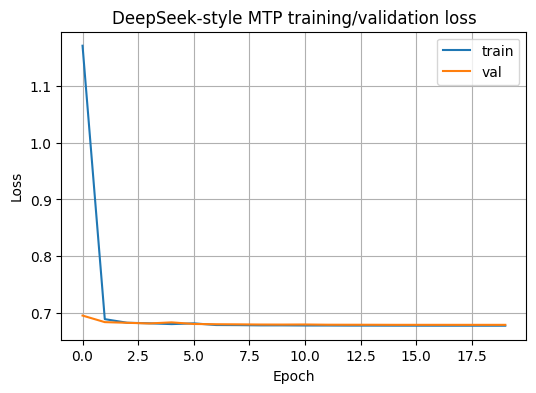

In [9]:
# cell_id: uOmO08H3QLE2
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DeepSeek‑style MTP training/validation loss')
plt.legend()
plt.grid(True)
plt.show()

## Test run: inspect predictions

In [10]:
# cell_id: jctmx_76QLE2
model.eval()
batch = next(iter(val_loader))
x = batch.to(device)

with torch.no_grad():
    logits = model(x)

B, T, V = logits.shape
print('Batch shape:', x.shape)
print('Logits shape:', logits.shape)

b = 0
t = min(5, T - 1) # Changed t to 20

x_cpu = x[b].cpu().tolist()
print('\nInput sequence (first 25 tokens):') # Adjusted print length
print(x_cpu[:25])

for k in range(1, K_FUTURE + 1):
    true_future_index = t + k
    true_token = x_cpu[true_future_index] if true_future_index < T else None

    print(f"\nInspecting position t={t}, future step k={k} (predicting token at t+k={true_future_index})")
    print('True future token:', true_token)

    if true_future_index < T:
        logits_bt = logits[b, t]
        probs_bt = logits_bt.softmax(dim=-1)
        topk = 5
        top_probs, top_indices = torch.topk(probs_bt, topk)

        print('Top predictions (token, prob):')
        for p, idx in zip(top_probs.cpu().tolist(), top_indices.cpu().tolist()):
            indicator = '✅' if true_token is not None and idx == true_token else '❌'
            print(f"  {idx:3d}  prob={p:.4f} {indicator}")
    else:
        print("  (Prediction beyond sequence length)")

Batch shape: torch.Size([128, 72])
Logits shape: torch.Size([128, 72, 10])

Input sequence (first 25 tokens):
[0, 7, 6, 9, 2, 3, 0, 7, 6, 9, 2, 3, 0, 7, 6, 9, 2, 3, 0, 7, 6, 9, 2, 3, 0]

Inspecting position t=5, future step k=1 (predicting token at t+k=6)
True future token: 0
Top predictions (token, prob):
    7  prob=0.4998 ❌
    0  prob=0.4997 ✅
    5  prob=0.0001 ❌
    3  prob=0.0001 ❌
    4  prob=0.0001 ❌

Inspecting position t=5, future step k=2 (predicting token at t+k=7)
True future token: 7
Top predictions (token, prob):
    7  prob=0.4998 ✅
    0  prob=0.4997 ❌
    5  prob=0.0001 ❌
    3  prob=0.0001 ❌
    4  prob=0.0001 ❌


### $\mathrm{1.\; Variables,\; Input\; \&\; Embeddings}$

* $\mathrm{B \in \mathbb{N}^+ \quad \text{(Batch size)}}$
* $\mathrm{T \in \mathbb{N}^+ \quad \text{(Sequence length)}}$
* $\mathrm{|V| \in \mathbb{N}^+ \quad \text{(Vocabulary size)}}$
* $\mathrm{d \in \mathbb{N}^+ \quad \text{(Hidden dimensionality)}}$

$$\mathrm{X \in \{0, \dots, |V|-1\}^{B \times T}}$$

$$\mathrm{E = TokenEmbed(X) \in \mathbb{R}^{B \times T \times d}}$$

$$\mathrm{P = PosEmbed(T) \in \mathbb{R}^{T \times d}}$$

$$\mathrm{H^{(0)} = E + P \in \mathbb{R}^{B \times T \times d}}$$

---

### $\mathrm{2.\; DeepSeek\text{-}V3\; Trunk\; Mechanics\; (61\; Layers)}$

#### $\mathrm{Layer\; Normalization\; (RMSNorm)}$
* $\mathrm{h \in \mathbb{R}^d \quad \text{(Hidden vector for a token)}}$
* $\mathrm{\epsilon \in \mathbb{R}^+ \quad \text{(Constant scalar to prevent zero division)}}$
* $\mathrm{g \in \mathbb{R}^d \quad \text{(Learnable scaling element)}}$
* $\mathrm{\odot \quad \text{(Hadamard element-wise multiplication operator)}}$

$$\mathrm{RMSNorm(h) = \frac{h}{\sqrt{\frac{1}{d}\sum_{i=1}^d h_i^2 + \epsilon}} \odot g}$$

#### $\mathrm{Multi\text{-}Head\; Latent\; Attention\; (MLA)}$
* $\mathrm{H \in \mathbb{R}^{B \times T \times d} \quad \text{(Normalized hidden layer input)}}$
* $\mathrm{W_Q, W_K, W_V \in \mathbb{R}^{d \times d} \quad \text{(Query, Key, and Value weights)}}$
* $\mathrm{W_{Q\ell}, W_{K\ell} \in \mathbb{R}^{d \times d_\ell} \quad \text{(Compression matrices, where } d_\ell \ll d)}$
* $\mathrm{Q_\ell, K_\ell \in \mathbb{R}^{B \times T \times d_\ell} \quad \text{(Compressed Query and Key states)}}$
* $\mathrm{d_\ell \in \mathbb{N}^+ \quad \text{(Compressed latent space dimension)}}$
* $\mathrm{W_O \in \mathbb{R}^{d \times d} \quad \text{(Final output projection weights)}}$

$$\mathrm{Q = H W_Q,\quad K = H W_K,\quad V = H W_V}$$

$$\mathrm{Q_\ell = Q W_{Q\ell},\quad K_\ell = K W_{K\ell}}$$

$$\mathrm{A = \text{softmax}\left(\frac{Q_\ell K_\ell^\top}{\sqrt{d_\ell}}\right)}$$

$$\mathrm{MLA(H) = A V W_O}$$

#### $\mathrm{DeepSeek\text{-}MoE\; Feedforward\; Layer}$
* $\mathrm{W_g \in \mathbb{R}^{d \times E} \quad \text{(Router gating weight matrix)}}$
* $\mathrm{E \in \mathbb{N}^+ \quad \text{(Total available sparse experts count)}}$
* $\mathrm{G \in \mathbb{R}^{B \times T \times E} \quad \text{(Gating probability distribution)}}$
* $\mathrm{W_{1,e} \in \mathbb{R}^{d \times d_{ff}},\; W_{2,e} \in \mathbb{R}^{d_{ff} \times d} \quad \text{(Down/up projections for expert e)}}$
* $\mathrm{\sigma \quad \text{(Non-linear activation function)}}$

$$\mathrm{G = \text{softmax}(H W_g)}$$

$$\mathrm{E_e(H) = \sigma(H W_{1,e}) W_{2,e}}$$

$$\mathrm{MoE(H) = \sum_{e=1}^{E} G_{e} \odot E_e(H)}$$

#### $\mathrm{Full\; Trunk\; Layer\; Integration}$
* $\mathrm{\ell \in \{0, \dots, 60\} \quad \text{(Block layer index)}}$
* $\mathrm{H_{\text{trunk}} \in \mathbb{R}^{B \times T \times d} \quad \text{(Core trunk output representation)}}$

$$\mathrm{H^{(\ell+1)} = H^{(\ell)} + MLA\left(RMSNorm(H^{(\ell)})\right) + MoE\left(RMSNorm(H^{(\ell)})\right)}$$

$$\mathrm{H_{\text{trunk}} = H^{(61)}}$$

---

### $\mathrm{3.\; DeepSeek\text{-}Style\; MTP\; Branch}$

* $\mathrm{RMSNorm_{\text{enorm}},\; RMSNorm_{\text{hnorm}} \quad \text{(Unique RMS layer norm setups)}}$
* $\mathrm{d_r \in \mathbb{N}^+ \quad \text{(Reduced bottleneck dimension, where } d_r < d)}$
* $\mathrm{W_{\text{proj}} \in \mathbb{R}^{d_r \times d} \quad \text{(Linear down-projection weights)}}$
* $\mathrm{TransformerLayer_{\text{mtp}} \quad \text{(Dense, non-MoE transformer block)}}$
* $\mathrm{W_{\text{head}} \in \mathbb{R}^{d_r \times |V|} \quad \text{(Shared target prediction weights)}}$
* $\mathrm{Z \in \mathbb{R}^{B \times T \times |V|} \quad \text{(Output logit matrices)}}$

$$\mathrm{H^{(1)} = RMSNorm_{\text{enorm}}(H_{\text{trunk}}) \in \mathbb{R}^{B \times T \times d}}$$

$$\mathrm{H^{(2)} = H^{(1)} W_{\text{proj}}^\top \in \mathbb{R}^{B \times T \times d_r}}$$

$$\mathrm{H^{(3)} = TransformerLayer_{\text{mtp}}(H^{(2)}) \in \mathbb{R}^{B \times T \times d_r}}$$

$$\mathrm{H^{(4)} = RMSNorm_{\text{hnorm}}(H^{(3)}) \in \mathbb{R}^{B \times T \times d_r}}$$

$$\mathrm{Z = H^{(4)} W_{\text{head}} \in \mathbb{R}^{B \times T \times |V|}}$$

---

### $\mathrm{4.\; Multi\text{-}Token\; Prediction\; Objective}$

* $\mathrm{K \in \mathbb{N}^+ \quad \text{(Forecasting step horizon constraint)}}$
* $\mathrm{k \in \{1, \dots, K\} \quad \text{(Target token offset tracking index)}}$
* $\mathrm{y^{(k)}_{b,t} \in \{0,\dots,|V|-1\} \quad \text{(Target token identity index at step } t+k)}$
* $\mathrm{p_{b,t} \in \mathbb{R}^{|V|} \quad \text{(Categorical distribution from softmax)}}$
* $\mathrm{N \in \mathbb{N}^+ \quad \text{(Count of valid, unmasked token calculations)}}$

$$\mathrm{\mathcal{L}_{\text{MTP}} = -\frac{1}{N} \sum_{b,t,k} \log p_{b,t}\left(y^{(k)}_{b,t}\right)}$$

---

### $\mathrm{5.\; Architectural\; Summary}$

$$\mathrm{\boxed{Z = RMSNorm_{\text{hnorm}} \left( TransformerLayer_{\text{mtp}} \left( RMSNorm_{\text{enorm}}(H_{\text{trunk}}) W_{\text{proj}}^\top \right) \right) W_{\text{head}}}}$$

$$\mathrm{where \quad H_{\text{trunk}} = DeepSeekMoE+MLA\_Trunk(E + P)}$$



$$\mathrm{y_{b,t}^{(k)} = X_{b,t+k}}$$

$$\mathrm{\textbf{Breakdown:}}$$
* $\mathrm{b = \text{Batch index}}$
* $\mathrm{t = \text{Current sequence position}}$
* $\mathrm{k = \text{How many steps into the future}}$
* $\mathrm{X = \text{The ground-truth sequence}}$

$$\mathrm{\textbf{So:}}$$
$$
\begin{align*}
y_{b,t}^{(1)} &= \text{the next token} \\
y_{b,t}^{(2)} &= \text{the second future token} \\
y_{b,t}^{(3)} &= \text{the third future token}
\end{align*}
$$



DeepSeek‑MTP computes K losses per position and sums them before backpropagation.

For each position
𝑡
, DeepSeek computes:

$$
\begin{align*}
\ell_{t,1} &= -\log p_t(x_{t+1}) \\
\ell_{t,2} &= -\log p_t(x_{t+2}) \\
\ell_{t,3} &= -\log p_t(x_{t+3}) \\
&\ \ \vdots \\
\ell_{t,K} &= -\log p_t(x_{t+K})
\end{align*}
$$

The model aggregates all losses across batch index $b$, time index $t$, and future-step index $k$:

$$
\mathcal{L}_{\text{MTP}} = \frac{1}{N} \sum_{b, t, k} \ell_{b, t, k}
$$
And THIS is what gradient descent minimizes.